# 02 — Preprocessing & Feature Engineering

**Project:** AI-Based Cybersecurity Threat Detection Using Machine Learning Techniques

This notebook does the "cleaning and feature work" between the raw data (Phase 1)
and the models (Phase 3):

1. **Median imputation** — fill missing / infinite numeric cells.
2. **Min-max scaling** — squash every number into [0, 1].
3. **One-hot encoding** — turn text features (protocol, service, flag) into 0/1 columns.
4. **SMOTE** — invent synthetic copies of the rare attack classes to balance training.
5. **Feature selection** — compare three methods (Pearson, mutual information, RFE).

The single most important rule, explained again because it is that important:
**everything is fitted on the TRAINING split and only *applied* to the test
split.** If we fitted the imputer/scaler/SMOTE on the whole dataset, the test
set would leak its answers into the model (data leakage) and the results would
lie.

Running this notebook saves the processed train/test splits and the
feature-selection comparison tables into `data/processed/`.

In [1]:
# --- Setup -----------------------------------------------------------------
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.data import loader as L
from src.data.preprocess import Preprocessor, apply_smote
from src.data import feature_selection as FS
from src.utils import config as C

pd.set_option("display.max_columns", 80)
OUT = C.DATA_PROCESSED_DIR
OUT.mkdir(parents=True, exist_ok=True)
print("Setup complete. Processed data will be saved to:", OUT)

Setup complete. Processed data will be saved to: D:\Cyber threat Detection\data\processed


## Part A — NSL-KDD preprocessing

**What is a "feature" here?** A feature is one measurable property of a network
connection. In NSL-KDD these include: how long the connection lasted
(`duration`), how many bytes were sent (`src_bytes`), which protocol was used
(`protocol_type`: tcp/udp/icmp), which service (`service`: http, ftp, ...), and
which TCP flag state the connection ended in (`flag`). Together, the 41 features
are the "sentence" a model reads to decide: normal or attack?

In [2]:
# Load the official NSL-KDD splits (Phase 1 loader).
nsl_train = L.load_nsl_kdd("train")
nsl_test  = L.load_nsl_kdd("test")

feature_cols = list(C.NSL_KDD_FEATURES)

Xtr_raw = nsl_train[feature_cols]
yte     = nsl_test[C.CATEGORY_COL]          # target of the TEST set
ytr     = nsl_train[C.CATEGORY_COL]         # target of the TRAIN set

print("train:", Xtr_raw.shape, "| test: shapes will follow after transform")

train: (125973, 41) | test: shapes will follow after transform


In [3]:
# 1+2+3. Build the Preprocessor and apply it train-first, test-second.
# The categorical (text) features of NSL-KDD are protocol_type, service, flag.
pp_nsl = Preprocessor(categorical_features=C.NSL_KDD_CATEGORICAL_FEATURES)

Xtr_nsl = pp_nsl.fit_transform(Xtr_raw)     # learns medians / mins / categories
Xte_nsl = pp_nsl.transform(nsl_test[feature_cols])   # reuses what train learned

print("Processed TRAIN shape:", Xtr_nsl.shape)
print("Processed TEST  shape:", Xte_nsl.shape)

# The one-hot step exploded "service" (70 possible values) into 70 columns.
print("\nColumns generated by one-hot encoding of 'service':")
print([c for c in Xtr_nsl.columns if c.startswith("service_")][:8], "...")

# Sanity check 1: scaling should put every numeric column in [0, 1].
mins, maxs = Xtr_nsl.min(), Xtr_nsl.max()
print("\nScaling check (min / max of every column):")
print(f"  min values range: {mins.min():.4f} .. {mins.max():.4f}")
print(f"  max values range: {maxs.min():.4f} .. {maxs.max():.4f}")

# Sanity check 2: no missing values may survive imputation.
print("\nMissing cells left after imputation (train):", int(Xtr_nsl.isna().sum().sum()))

Processed TRAIN shape: (125973, 122)
Processed TEST  shape: (22544, 122)

Columns generated by one-hot encoding of 'service':
['service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns'] ...

Scaling check (min / max of every column):
  min values range: 0.0000 .. 0.0000
  max values range: 0.0000 .. 1.0000

Missing cells left after imputation (train): 0


In [4]:
# 4. SMOTE — balance the rare attack classes in TRAINING only.
before = ytr.value_counts().to_dict()

Xtr_nsl_bal, ytr_nsl_bal = apply_smote(
    Xtr_nsl, ytr, sampling_strategy={"R2L": 15_000, "U2R": 15_000}
)
after = ytr_nsl_bal.value_counts().to_dict()

print("Class counts BEFORE SMOTE:  ", {k: int(v) for k, v in before.items()})
print("Class counts AFTER  SMOTE:  ", {k: int(v) for k, v in after.items()})
print(f"\nTrain grew from {len(Xtr_nsl):,} -> {len(Xtr_nsl_bal):,} rows.")
print("Test set is untouched (never SMOTE the exam!).")

Class counts BEFORE SMOTE:   {'Normal': 67343, 'DoS': 45927, 'Probe': 11656, 'R2L': 995, 'U2R': 52}
Class counts AFTER  SMOTE:   {'Normal': 67343, 'DoS': 45927, 'R2L': 15000, 'U2R': 15000, 'Probe': 11656}

Train grew from 125,973 -> 154,926 rows.
Test set is untouched (never SMOTE the exam!).


In [5]:
# Save the processed NSL-KDD splits + the fitted pipeline for later reuse.
# The fitted Preprocessor is saved too so that the web API (Phase 5) can
# transform a single incoming row in exactly the same way the model saw
# training data — a model must never meet an untransformed row.

Xtr_nsl_bal.to_pickle(OUT / "nslkdd_train_X.pkl")
ytr_nsl_bal.to_pickle(OUT / "nslkdd_train_y.pkl")
Xte_nsl.to_pickle(OUT / "nslkdd_test_X.pkl")
yte.to_pickle(OUT / "nslkdd_test_y.pkl")
joblib.dump(pp_nsl, OUT / "nslkdd_preprocessor.joblib")

# A LabelEncoder maps "Normal" <-> 0, "DoS" <-> 1, ... for the models.
le_nsl = LabelEncoder().fit(ytr)
joblib.dump(le_nsl, OUT / "nslkdd_label_encoder.joblib")
print("Saved NSL-KDD processed splits + preprocessor + label encoder.")
print("   files ->", sorted(p.name for p in OUT.glob("nslkdd*")))

Saved NSL-KDD processed splits + preprocessor + label encoder.
   files -> ['nslkdd_label_encoder.joblib', 'nslkdd_preprocessor.joblib', 'nslkdd_test_X.pkl', 'nslkdd_test_y.pkl', 'nslkdd_train_X.pkl', 'nslkdd_train_y.pkl']


## Part B — CICIDS2017 preprocessing

CICIDS2017 has ~2.8 million flows, 80% of them normal. Two problems to solve
before modelling:

* **Size** — we can't SMOTE 2.3M normal rows. We use a *capped* sample: keep
  every rare attack row (Heartbleed = 11, Infiltration = 36) and downsize the
  giant classes to 15,000 each. Rare classes are preserved 100%.
* **Infinity** — flows with duration 0 produce `inf` in the rate columns, which
  the imputer must fill with the median.

Because CICIDS2017 has no official train/test split, we create our own
stratified 80/20 split.

In [6]:
# Capped, class-preserving sample: two streaming passes over the CSVs.
cic = L.load_cicids2017_capped(per_class_cap=15_000)
print("Capped CICIDS2017 sample:", cic.shape)
print(cic[C.CATEGORY_COL].value_counts().to_string())

Capped CICIDS2017 sample: (78028, 82)
attack_category
DDoS            15000
Normal          15000
PortScan        15000
DoS             15000
Brute Force     13835
Web Attack       2180
Botnet           1966
Infiltration       36
Heartbleed         11


In [7]:
# Stratified 80/20 split — same proportion of every class in both parts.
cic_train, cic_test = train_test_split(
    cic, test_size=0.2, stratify=cic[C.CATEGORY_COL], random_state=C.RANDOM_STATE
)

Xtr_cic_raw = cic_train.drop(columns=[C.TYPE_COL, C.CATEGORY_COL, C.IS_ATTACK_COL, C.SOURCE_COL])
ytr_cic     = cic_train[C.CATEGORY_COL]
Xte_cic_raw = cic_test.drop(columns=[C.TYPE_COL, C.CATEGORY_COL, C.IS_ATTACK_COL, C.SOURCE_COL])
yte_cic     = cic_test[C.CATEGORY_COL]

print("train rows:", len(cic_train), "| test rows:", len(cic_test))

# How dirty is the raw train before cleaning?
inf_count = int(np.isinf(Xtr_cic_raw.to_numpy(dtype=float)).sum())
nan_count = int(Xtr_cic_raw.isna().sum().sum())
print(f"Raw train: {nan_count:,} NaN cells and {inf_count:,} Inf cells to clean.")

train rows: 62422 | test rows: 15606
Raw train: 51 NaN cells and 111 Inf cells to clean.


In [8]:
# CICIDS2017 has NO categorical features — all 78 are numeric.
pp_cic = Preprocessor(categorical_features=[])

Xtr_cic = pp_cic.fit_transform(Xtr_cic_raw)
Xte_cic = pp_cic.transform(Xte_cic_raw)

print("Processed TRAIN shape:", Xtr_cic.shape)
print("Processed TEST  shape:", Xte_cic.shape)
print("Missing cells left after imputation (train):", int(Xtr_cic.isna().sum().sum()))
print("Scaling check — column max range:", f"{Xtr_cic.max().max():.4f}")

# Constant (zero-variance) features: give a model no information at all.
zero_var = [c for c in Xtr_cic.columns if Xtr_cic[c].nunique() <= 1]
print("\nZero-variance features in CICIDS2017 train:")
print(zero_var or "  none")

Processed TRAIN shape: (62422, 78)
Processed TEST  shape: (15606, 78)
Missing cells left after imputation (train): 0
Scaling check — column max range: 1.0000

Zero-variance features in CICIDS2017 train:
['bwd_psh_flags', 'bwd_urg_flags', 'fwd_avg_bytes_bulk', 'fwd_avg_packets_bulk', 'fwd_avg_bulk_rate', 'bwd_avg_bytes_bulk', 'bwd_avg_packets_bulk', 'bwd_avg_bulk_rate']


In [9]:
# SMOTE — balance every class up to the majority (15,000 each).
before_cic = ytr_cic.value_counts().to_dict()
Xtr_cic_bal, ytr_cic_bal = apply_smote(Xtr_cic, ytr_cic, sampling_strategy="auto")
after_cic = ytr_cic_bal.value_counts().to_dict()

print("Class counts BEFORE SMOTE:")
for k in sorted(before_cic):
    print(f"   {k:<15} {int(before_cic[k]):>7,}")
print("Class counts AFTER SMOTE (all equal = balanced):")
for k in sorted(after_cic):
    print(f"   {k:<15} {int(after_cic[k]):>7,}")
print(f"\nTrain grew from {len(Xtr_cic):,} -> {len(Xtr_cic_bal):,} rows.")

Class counts BEFORE SMOTE:
   Botnet            1,572
   Brute Force      11,068
   DDoS             12,000
   DoS              12,000
   Heartbleed            9
   Infiltration         29
   Normal           12,000
   PortScan         12,000
   Web Attack        1,744
Class counts AFTER SMOTE (all equal = balanced):
   Botnet           12,000
   Brute Force      12,000
   DDoS             12,000
   DoS              12,000
   Heartbleed       12,000
   Infiltration     12,000
   Normal           12,000
   PortScan         12,000
   Web Attack       12,000

Train grew from 62,422 -> 108,000 rows.


In [10]:
# Save the processed CICIDS2017 splits + pipeline artifacts.
Xtr_cic_bal.to_pickle(OUT / "cicids_train_X.pkl")
ytr_cic_bal.to_pickle(OUT / "cicids_train_y.pkl")
Xte_cic.to_pickle(OUT / "cicids_test_X.pkl")
yte_cic.to_pickle(OUT / "cicids_test_y.pkl")
joblib.dump(pp_cic, OUT / "cicids_preprocessor.joblib")
le_cic = LabelEncoder().fit(ytr_cic)
joblib.dump(le_cic, OUT / "cicids_label_encoder.joblib")
print("Saved CICIDS2017 processed splits + preprocessor + label encoder.")
print("   files ->", sorted(p.name for p in OUT.glob("cicids*")))

Saved CICIDS2017 processed splits + preprocessor + label encoder.
   files -> ['cicids_label_encoder.joblib', 'cicids_preprocessor.joblib', 'cicids_test_X.pkl', 'cicids_test_y.pkl', 'cicids_train_X.pkl', 'cicids_train_y.pkl']


## Part C — Feature selection (three methods, one comparison)

Feature selection runs on the preprocessed, **pre-SMOTE** training data — we do
not want invented synthetic rows deciding which real features matter.

* **Pearson correlation** — linear relationship between each feature and the class.
* **Mutual information** — any (even non-linear) relationship; "bits of info
  gained about the class".
* **RFE (Recursive Feature Elimination)** — repeatedly train Logistic
  Regression, delete the least important features, repeat.

The comparison table records each method's ranking and whether each feature is
kept in the top 30. It is saved as CSV for the thesis.

In [11]:
# --- Feature selection: NSL-KDD -----------------------------------------
nsl_sel = FS.compare_methods(
    Xtr_nsl, ytr,              # pre-SMOTE train
    dataset_name="NSL-KDD",
    top_k=30,
    out_path=OUT / "nslkdd_feature_selection.csv",
)
print()
print("Top 10 features by mutual information:")
print(nsl_sel.sort_values("mi_rank")[["feature", "mi_score"]].head(10).to_string(index=False))

Running all three feature-selection methods on NSL-KDD ...


Saved comparison table -> D:\Cyber threat Detection\data\processed\nslkdd_feature_selection.csv
  Pearson     kept 30 features
  Mutual info kept 30 features
  RFE         kept 30 features
  Features all three methods agree on: 15

Top 10 features by mutual information:
               feature  mi_score
             src_bytes  0.715393
         diff_srv_rate  0.508292
         same_srv_rate  0.471943
             dst_bytes  0.459941
dst_host_diff_srv_rate  0.452194
    dst_host_srv_count  0.418825
                 count  0.413996
dst_host_same_srv_rate  0.405847
  dst_host_serror_rate  0.400641
           serror_rate  0.390135


In [12]:
# --- Feature selection: CICIDS2017 -------------------------------------
cic_sel = FS.compare_methods(
    Xtr_cic, ytr_cic,          # pre-SMOTE train
    dataset_name="CICIDS2017",
    top_k=30,
    out_path=OUT / "cicids_feature_selection.csv",
)
print()
print("Top 10 features by mutual information:")
print(cic_sel.sort_values("mi_rank")[["feature", "mi_score"]].head(10).to_string(index=False))

Running all three feature-selection methods on CICIDS2017 ...


Saved comparison table -> D:\Cyber threat Detection\data\processed\cicids_feature_selection.csv
  Pearson     kept 30 features
  Mutual info kept 30 features
  RFE         kept 30 features
  Features all three methods agree on: 7

Top 10 features by mutual information:
                    feature  mi_score
        average_packet_size  1.447151
         packet_length_mean  1.422680
          packet_length_std  1.291820
     packet_length_variance  1.291396
          subflow_fwd_bytes  1.255720
           destination_port  1.255401
total_length_of_fwd_packets  1.252389
          fwd_header_length  1.244998
        fwd_header_length_1  1.243412
     init_win_bytes_forward  1.233739


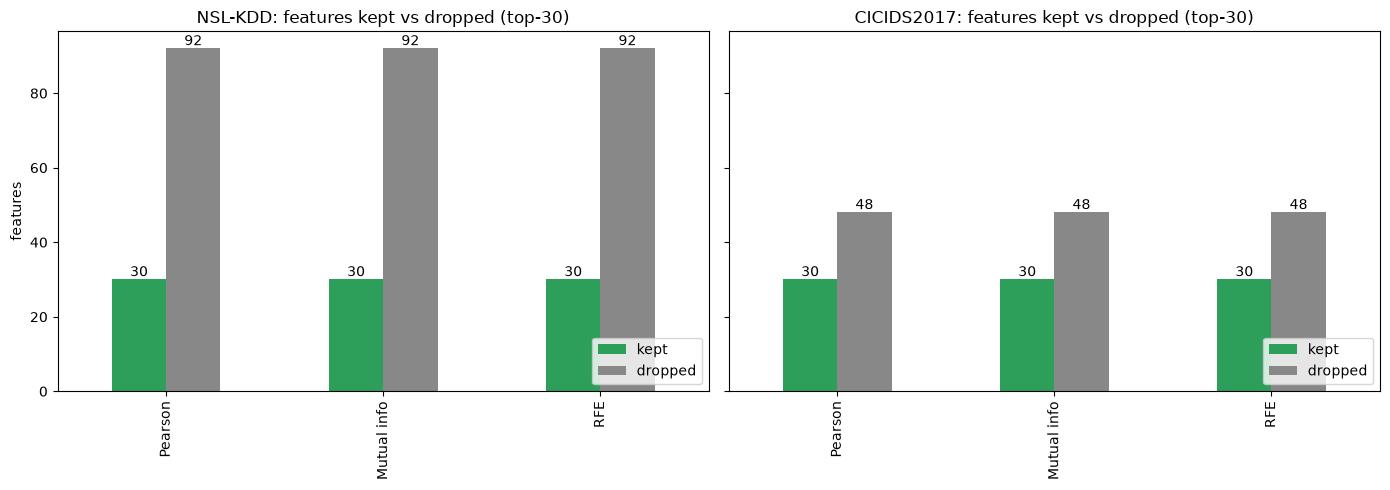

NSL-KDD features all 3 methods agree on: 15
CICIDS2017 features all 3 methods agree on: 7

Agreement list (NSL-KDD): ['flag_S0', 'dst_host_serror_rate', 'srv_serror_rate', 'serror_rate', 'same_srv_rate', 'count', 'dst_host_same_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_count', 'dst_host_srv_diff_host_rate', 'logged_in', 'dst_host_srv_count', 'service_http', 'service_private', 'diff_srv_rate']

Agreement list (CICIDS2017): ['packet_length_variance', 'packet_length_std', 'average_packet_size', 'bwd_packet_length_max', 'bwd_packet_length_mean', 'avg_bwd_segment_size', 'init_win_bytes_backward']


In [13]:
# --- Visual comparison: how much do the methods agree? ------------------
import matplotlib.pyplot as plt
import seaborn as sns

def agreement_table(tbl):
    """Rows: method-pairs. Columns: kept / dropped. Diagonal = total kept."""
    n = len(tbl)
    out = {}
    for mname, col in [("Pearson", "pearson_kept"), ("Mutual info", "mi_kept"), ("RFE", "rfe_kept")]:
        out[mname] = {"kept": int(tbl[col].sum()), "dropped": n - int(tbl[col].sum())}
    return pd.DataFrame(out).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (name, tbl) in zip(axes, [("NSL-KDD", nsl_sel), ("CICIDS2017", cic_sel)]):
    at = agreement_table(tbl)
    at.plot(kind="bar", ax=ax, color=["#2e9e5b", "#888888"])
    ax.set_title(f"{name}: features kept vs dropped (top-30)")
    ax.set_ylabel("features")
    ax.legend(loc="lower right")
    for container in ax.containers:
        ax.bar_label(container)
fig.tight_layout()
fig.savefig(C.REPORTS_DIR / "figures" / "feature_selection_comparison.png", dpi=120)
plt.show()

# How many features do ALL THREE methods agree on?
agree_nsl = nsl_sel[(nsl_sel["pearson_kept"]) & (nsl_sel["mi_kept"]) & (nsl_sel["rfe_kept"])]
agree_cic = cic_sel[(cic_sel["pearson_kept"]) & (cic_sel["mi_kept"]) & (cic_sel["rfe_kept"])]
print("NSL-KDD features all 3 methods agree on:", len(agree_nsl))
print("CICIDS2017 features all 3 methods agree on:", len(agree_cic))
print("\nAgreement list (NSL-KDD):", list(agree_nsl["feature"]))
print("\nAgreement list (CICIDS2017):", list(agree_cic["feature"]))

## Summary

* All four preprocessing steps run **train-first, test-second** to prevent data
  leakage. SMOTE runs on the training split only.
* NSL-KDD: 41 raw features became **122 numeric columns** (one-hot encoding);
  the rare U2R/R2L classes were grown from 52/995 to 15,000 rows each.
* CICIDS2017: a class-capped sample kept all rare attacks; Inf/NaN were
  imputed with the median; SMOTE balanced all 9 classes to 15,000 rows.
* Three feature-selection methods produced comparison tables
  (`data/processed/*_feature_selection.csv`) for both datasets.
* Phase 3 will train the four models on these processed splits and grid-search
  their hyperparameters.